# Exploratieve Data-analyse (EDA)
## Misinformatie Detectie op Mastodon

Dit notebook verkent de gecombineerde dataset vóór de modellering.

In [3]:
%pip install wordcloud

Note: you may need to restart the kernel to use updated packages.


You should consider upgrading via the 'c:\Users\Gebruiker\AppData\Local\Programs\Python\Python310\python.exe -m pip install --upgrade pip' command.


In [4]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')

print('Libraries geladen!')

Libraries geladen!


In [5]:
# Laad de gecombineerde dataset
train = pd.read_csv('../data/processed/train_combined.csv')
val   = pd.read_csv('../data/processed/val_combined.csv')
test  = pd.read_csv('../data/processed/test_combined.csv')

print(f'Train: {len(train)}')
print(f'Val:   {len(val)}')
print(f'Test:  {len(test)}')
train.head()

Train: 10324
Val:   1306
Test:  1289


,clean_text,label,source_trust_score,source,char_length,word_count,length_category,id,statement,subject,...,replies_count,reblogs_count,favourites_count,account_username,account_followers,account_following,account_statuses,account_created_at,account_bot,hashtag_used
0,says the donald j.trump foundations money is h...,0,1.00,liar,55,9,middellang,13064.json,Says the Donald J.Trump Foundations money is h...,candidates-biography,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,the u.s. economy is recovering slower than europe,0,4.17,liar,49,8,kort,5866.json,The U.S. economy is recovering slower than Europe,economy,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,says texas did not bail out a loan program he ...,0,3.77,liar,88,15,middellang,5000.json,Says Texas did not bail out a loan program he ...,"agriculture,candidates-biography",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,"both china and japan have surpassed us, with j...",1,5.62,liar,108,20,middellang,16.json,"Both China and Japan have surpassed us, with J...",energy,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,not even old gen. eisenhower saluted military ...,0,4.13,liar,69,10,middellang,9960.json,Not even old Gen. Eisenhower saluted military ...,"history,military",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


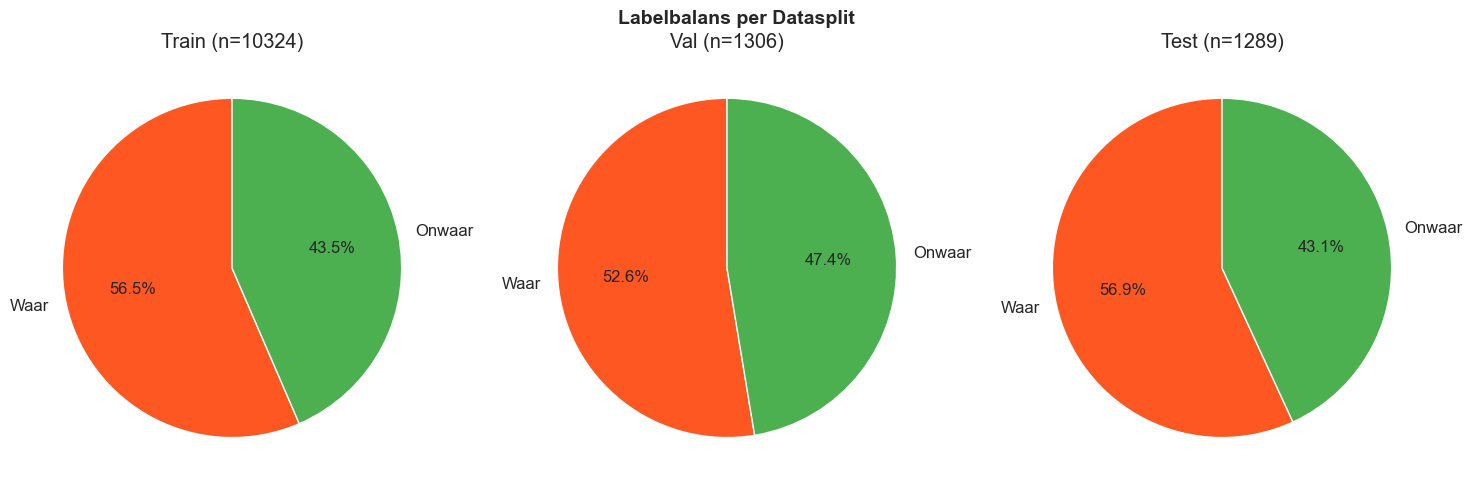

In [6]:
# ── 1. LABELBALANS ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
label_map = {0: 'Onwaar', 1: 'Waar'}

for ax, (df, name) in zip(axes, [(train, 'Train'), (val, 'Val'), (test, 'Test')]):
    counts = df['label'].map(label_map).value_counts()
    ax.pie(counts, labels=counts.index, autopct='%1.1f%%',
           colors=['#FF5722', '#4CAF50'], startangle=90)
    ax.set_title(f'{name} (n={len(df)})')

plt.suptitle('Labelbalans per Datasplit', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/figures/eda_labelbalans.png', dpi=150, bbox_inches='tight')
plt.show()

C:\Users\Gebruiker\AppData\Local\Temp\ipykernel_20152\2859146318.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=train, x='label_str', y='char_length',


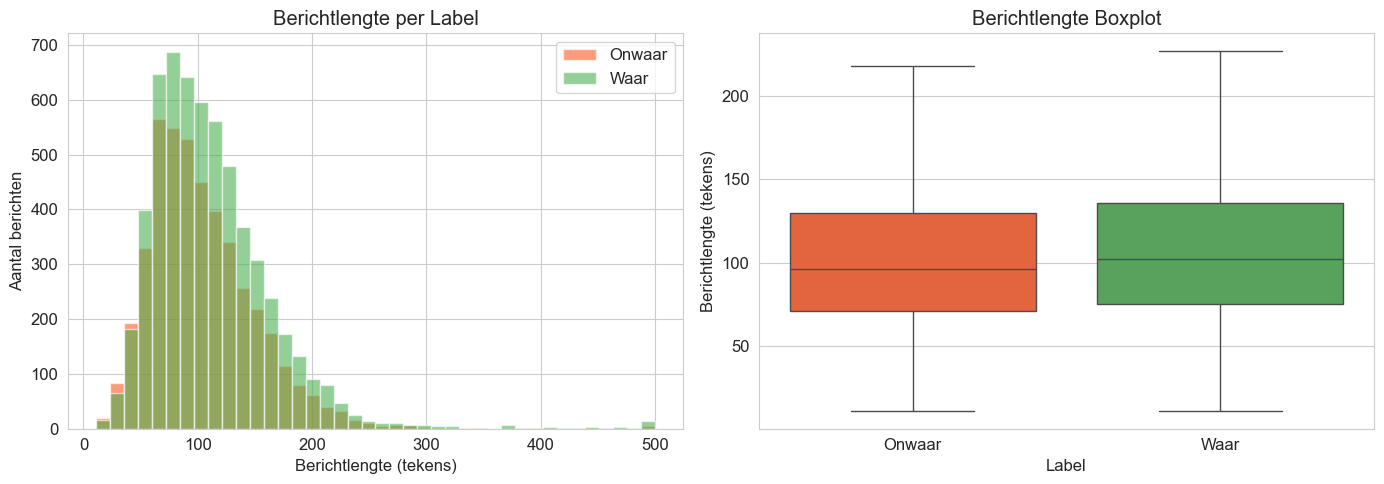

Gemiddelde lengte per label:
                 mean        std    50%
label_str                              
Onwaar     104.997329  56.858440   96.0
Waar       112.854595  92.202411  102.0


In [7]:
# ── 2. BERICHTLENGTE DISTRIBUTIE ────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
for label, color in [(0, '#FF5722'), (1, '#4CAF50')]:
    subset = train[train['label'] == label]['char_length']
    axes[0].hist(subset.clip(upper=500), bins=40, alpha=0.6,
                 color=color, label='Onwaar' if label == 0 else 'Waar')
axes[0].set_xlabel('Berichtlengte (tekens)')
axes[0].set_ylabel('Aantal berichten')
axes[0].set_title('Berichtlengte per Label')
axes[0].legend()

# Boxplot
train['label_str'] = train['label'].map({0: 'Onwaar', 1: 'Waar'})
sns.boxplot(data=train, x='label_str', y='char_length',
            palette={'Onwaar': '#FF5722', 'Waar': '#4CAF50'},
            ax=axes[1], showfliers=False)
axes[1].set_xlabel('Label')
axes[1].set_ylabel('Berichtlengte (tekens)')
axes[1].set_title('Berichtlengte Boxplot')

plt.tight_layout()
plt.savefig('../results/figures/eda_berichtlengte.png', dpi=150, bbox_inches='tight')
plt.show()

print('Gemiddelde lengte per label:')
print(train.groupby('label_str')['char_length'].describe()[['mean','std','50%']])

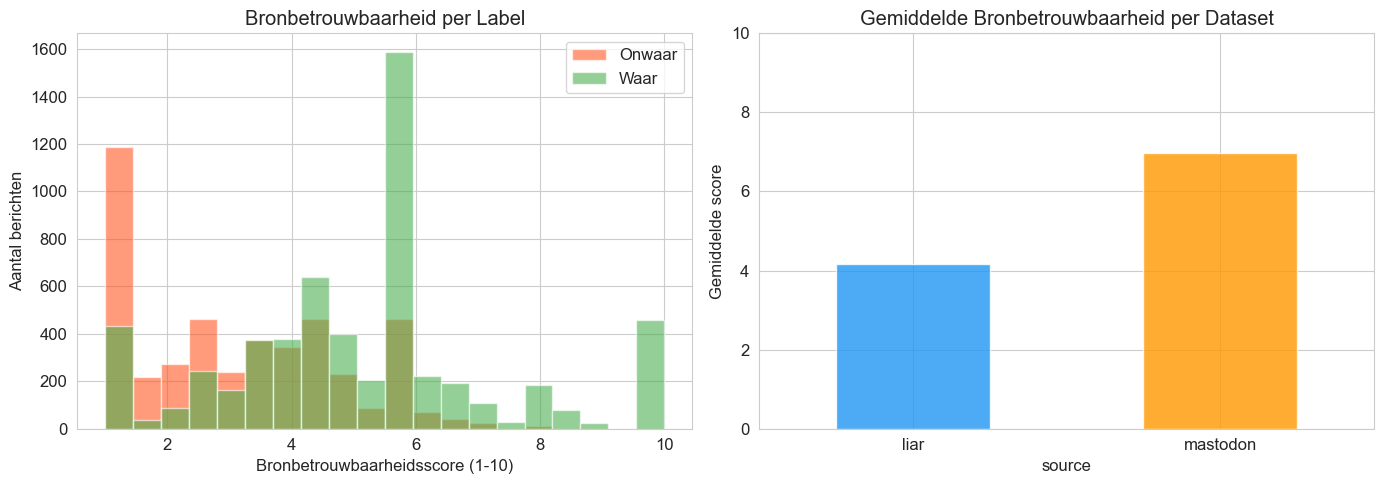

In [8]:
# ── 3. BRONBETROUWBAARHEID ──────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
for label, color in [(0, '#FF5722'), (1, '#4CAF50')]:
    subset = train[train['label'] == label]['source_trust_score']
    axes[0].hist(subset, bins=20, alpha=0.6,
                 color=color, label='Onwaar' if label == 0 else 'Waar')
axes[0].set_xlabel('Bronbetrouwbaarheidsscore (1-10)')
axes[0].set_ylabel('Aantal berichten')
axes[0].set_title('Bronbetrouwbaarheid per Label')
axes[0].legend()

# Per bron
trust_by_source = train.groupby('source')['source_trust_score'].mean()
trust_by_source.plot(kind='bar', ax=axes[1], color=['#2196F3', '#FF9800'], alpha=0.8)
axes[1].set_title('Gemiddelde Bronbetrouwbaarheid per Dataset')
axes[1].set_ylabel('Gemiddelde score')
axes[1].set_ylim(0, 10)
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('../results/figures/eda_bronbetrouwbaarheid.png', dpi=150, bbox_inches='tight')
plt.show()

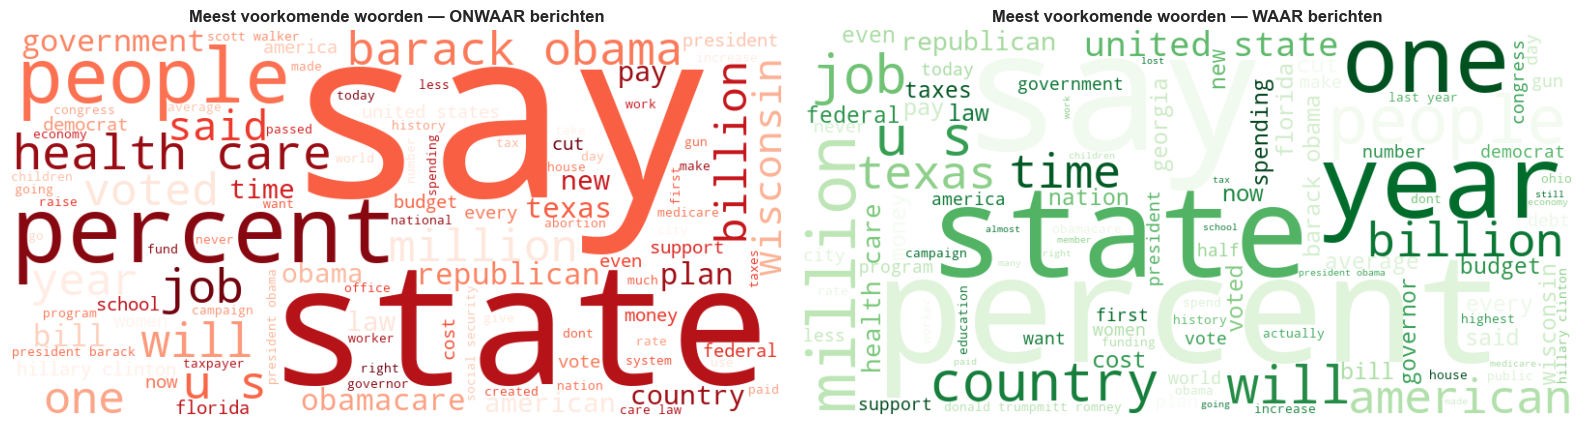

In [9]:
# ── 4. WORDCLOUD ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, label, color, title in [
    (axes[0], 0, 'Reds', 'Meest voorkomende woorden — ONWAAR berichten'),
    (axes[1], 1, 'Greens', 'Meest voorkomende woorden — WAAR berichten'),
]:
    text = ' '.join(train[train['label'] == label]['clean_text'].dropna().tolist())
    wc = WordCloud(
        width=800, height=400,
        background_color='white',
        colormap=color,
        max_words=100,
    ).generate(text)
    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(title, fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('../results/figures/eda_wordclouds.png', dpi=150, bbox_inches='tight')
plt.show()

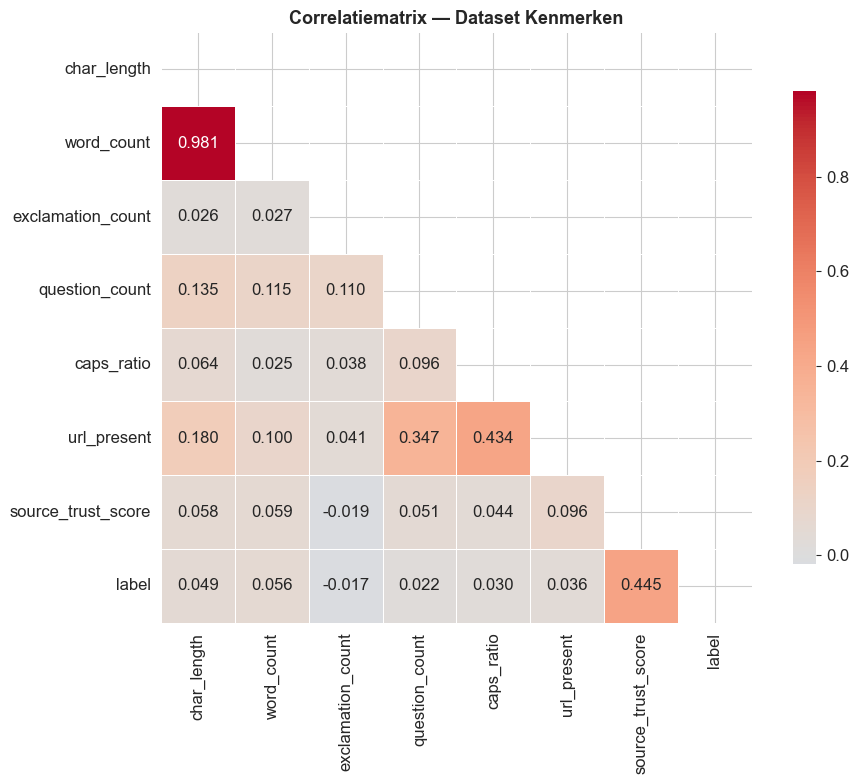


Correlatie met label:
source_trust_score    0.444717
word_count            0.056297
char_length           0.049380
url_present           0.035553
caps_ratio            0.030432
question_count        0.022331
exclamation_count    -0.016586
Name: label, dtype: float64


In [10]:
# ── 5. CORRELATIEANALYSE ────────────────────────────────────────────
numeric_features = ['char_length', 'word_count', 'exclamation_count',
                    'question_count', 'caps_ratio', 'url_present', 'source_trust_score', 'label']

corr_df = train[numeric_features].corr()

plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_df, dtype=bool))
sns.heatmap(corr_df, annot=True, fmt='.3f', cmap='coolwarm',
            center=0, mask=mask, square=True, linewidths=0.5,
            cbar_kws={'shrink': 0.8})
plt.title('Correlatiematrix — Dataset Kenmerken', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/figures/eda_correlatiematrix.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nCorrelatie met label:')
print(corr_df['label'].drop('label').sort_values(ascending=False))

## Samenvatting EDA

Noteer hier je bevindingen na het uitvoeren van bovenstaande analyses:

- **Labelbalans**: ...
- **Berichtlengte**: ...
- **Bronbetrouwbaarheid**: ...
- **Taalgebruik**: ...
- **Opvallende correlaties**: ...